# Task 3 – Country-Wise Netflix Content Analysis
**Auspify Technologies – Data Analysis Using Python Internship**

**Goal:** Analyze Netflix content availability across different countries.

**Workflow:** Extract & clean country information → Count content by country → Identify top content-producing countries → Create charts & rankings → Generate business insights

## Step 1: Extract and clean country information

In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
RED, BLACK = '#E50914', '#221F1F'
os.makedirs('charts', exist_ok=True)

path = '../Task1/netflix_cleaned.csv' if os.path.exists('../Task1/netflix_cleaned.csv') else 'netflix_cleaned.csv'
df = pd.read_csv(path, parse_dates=['date_added'])
print('Loaded:', path, '| Shape:', df.shape)
df[['title', 'type', 'country', 'year_added']].head()

Loaded: ../Task1/netflix_cleaned.csv | Shape: (8786, 15)


,title,type,country,year_added
0,Dick Johnson Is Dead,Movie,United States,2021
1,Ganglands,TV Show,France,2021
2,Midnight Mass,TV Show,United States,2021
3,Confessions of an Invisible Girl,Movie,Brazil,2021
4,Sankofa,Movie,United States,2021


In [16]:
# Inspect the country column
print('Unique country values :', df['country'].nunique())
print('"Unknown" (placeholder from Task 1):', (df['country'] == 'Unknown').sum())
print('Values containing a comma (multi-country titles):', df['country'].str.contains(',').sum())
print('Leading/trailing spaces:', (df['country'] != df['country'].str.strip()).sum())

Unique country values : 86
"Unknown" (placeholder from Task 1): 287
Values containing a comma (multi-country titles): 0
Leading/trailing spaces: 0


**Findings:** each title has a single country value, there are no multi-country entries to split, and 287 titles are `Unknown` (the "Not Given" placeholder from Task 1). The code below still handles multi-country values safely, so it keeps working if the data changes.

In [17]:
# Clean: trim spaces, split any multi-country values into separate rows
df_c = df.copy()
df_c['country'] = df_c['country'].str.strip().str.split(',')
df_c = df_c.explode('country')
df_c['country'] = df_c['country'].str.strip()

# Separate known countries from "Unknown" for ranking
known = df_c[df_c['country'] != 'Unknown'].copy()
print(f"Titles with a known country : {len(known):,}")
print(f"Titles excluded (Unknown)   : {(df_c['country'] == 'Unknown').sum():,}")
print(f"Countries in the dataset    : {known['country'].nunique()}")

Titles with a known country : 8,499
Titles excluded (Unknown)   : 287
Countries in the dataset    : 85


*Data note:* the list includes historical names such as **Soviet Union** and **West Germany**. They are kept as they appear in the data and have very few titles, so they do not affect the rankings.

## Step 2: Calculate content count by country

In [18]:
ranking = (known.groupby('country')
                .agg(titles=('title', 'count'),
                     movies=('type', lambda s: (s == 'Movie').sum()),
                     tv_shows=('type', lambda s: (s == 'TV Show').sum()))
                .sort_values('titles', ascending=False))
ranking['share_pct'] = (ranking['titles'] / ranking['titles'].sum() * 100).round(2)
ranking['cumulative_pct'] = ranking['share_pct'].cumsum().round(2)
ranking['tv_share_pct'] = (ranking['tv_shows'] / ranking['titles'] * 100).round(1)
ranking.insert(0, 'rank', range(1, len(ranking) + 1))

ranking.to_csv('country_ranking.csv')   # ranking report
print('Ranking report saved: country_ranking.csv')
ranking.head(15)

Ranking report saved: country_ranking.csv


,rank,titles,movies,tv_shows,share_pct,cumulative_pct,tv_share_pct
country,,,,,,,
United States,1,3240,2395,845,38.12,38.12,26.1
India,2,1056,975,81,12.42,50.54,7.7
United Kingdom,3,638,387,251,7.51,58.05,39.3
Pakistan,4,420,71,349,4.94,62.99,83.1
Canada,5,271,187,84,3.19,66.18,31.0
Japan,6,259,87,172,3.05,69.23,66.4
South Korea,7,214,49,165,2.52,71.75,77.1
France,8,213,148,65,2.51,74.26,30.5
Spain,9,182,129,53,2.14,76.40,29.1


## Step 3: Identify top content-producing countries

In [19]:
total_known = ranking['titles'].sum()
top5 = ranking.head(5)
top10 = ranking.head(10)

print('TOP 10 CONTENT-PRODUCING COUNTRIES')
print('-' * 45)
for _, r in top10.iterrows():
    print(f"{int(r['rank']):>2}. {r.name:<16} {int(r['titles']):>5,} titles  ({r['share_pct']:>5.1f}%)")

print()
print(f"Top 1  ({ranking.index[0]}) share : {ranking['share_pct'].iloc[0]:.1f}%")
print(f"Top 5  countries share      : {top5['titles'].sum() / total_known * 100:.1f}%")
print(f"Top 10 countries share      : {top10['titles'].sum() / total_known * 100:.1f}%")
print(f"Countries with 5 titles or fewer: {(ranking['titles'] <= 5).sum()} of {len(ranking)}")

TOP 10 CONTENT-PRODUCING COUNTRIES
---------------------------------------------
 1. United States    3,240 titles  ( 38.1%)
 2. India            1,056 titles  ( 12.4%)
 3. United Kingdom     638 titles  (  7.5%)
 4. Pakistan           420 titles  (  4.9%)
 5. Canada             271 titles  (  3.2%)
 6. Japan              259 titles  (  3.0%)
 7. South Korea        214 titles  (  2.5%)
 8. France             213 titles  (  2.5%)
 9. Spain              182 titles  (  2.1%)
10. Mexico             138 titles  (  1.6%)

Top 1  (United States) share : 38.1%
Top 5  countries share      : 66.2%
Top 10 countries share      : 78.0%
Countries with 5 titles or fewer: 33 of 85


## Step 4: Create charts and rankings
### 4.1 Top 15 countries by number of titles

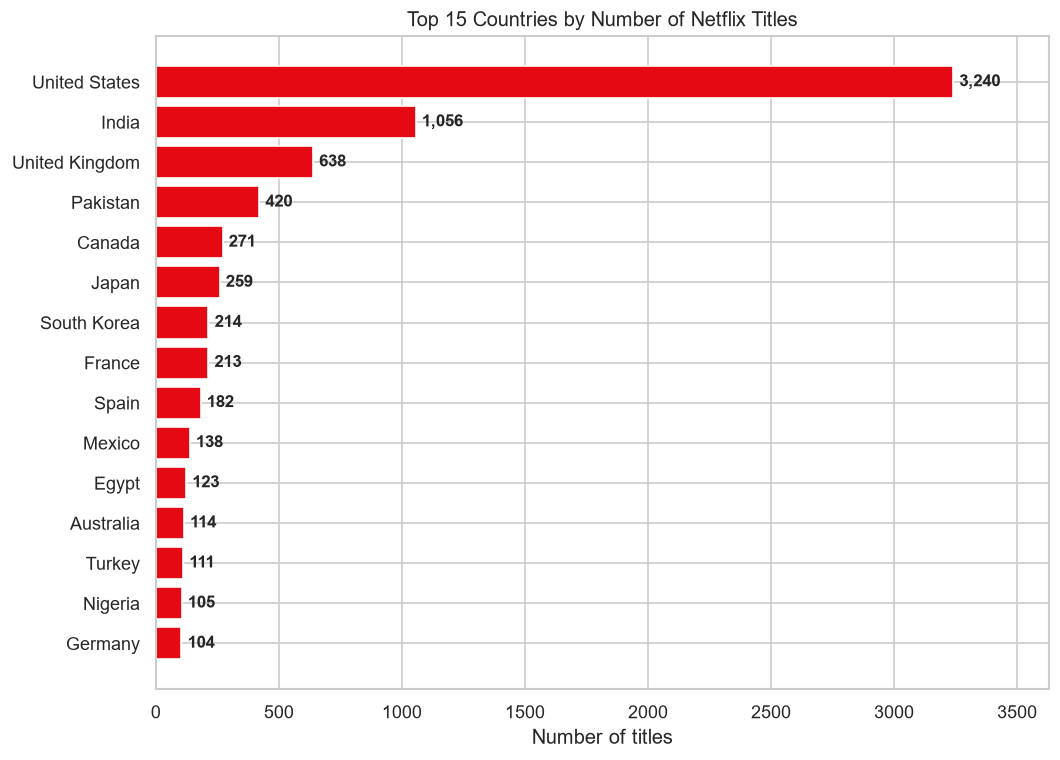

In [20]:
top15 = ranking.head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(9, 6.5))
ax.barh(top15.index, top15['titles'], color=RED)
for y, v in enumerate(top15['titles']):
    ax.text(v + 25, y, f'{v:,}', va='center', fontsize=10, fontweight='bold')
ax.set_title('Top 15 Countries by Number of Netflix Titles')
ax.set_xlabel('Number of titles')
ax.set_xlim(0, top15['titles'].max() * 1.12)
plt.tight_layout()
plt.savefig('charts/01_top15_countries.png', bbox_inches='tight')
plt.show()

### 4.2 How concentrated is the catalogue? (cumulative share)

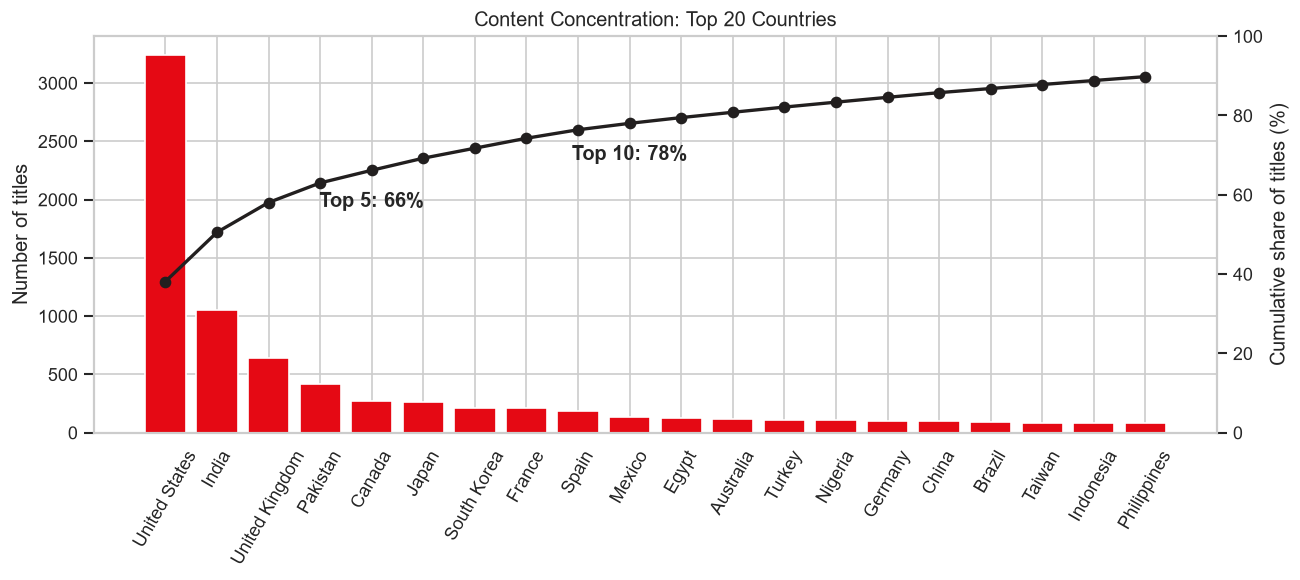

In [21]:
top20 = ranking.head(20)

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(top20.index, top20['titles'], color=RED)
ax1.set_ylabel('Number of titles')
ax1.tick_params(axis='x', rotation=60)
ax2 = ax1.twinx()
ax2.plot(top20.index, top20['cumulative_pct'], color=BLACK, marker='o', linewidth=2)
ax2.set_ylabel('Cumulative share of titles (%)')
ax2.set_ylim(0, 100)
ax2.grid(False)
for rank in (5, 10):
    ax2.annotate(f"Top {rank}: {top20['cumulative_pct'].iloc[rank - 1]:.0f}%",
                 (rank - 1, top20['cumulative_pct'].iloc[rank - 1]),
                 textcoords='offset points', xytext=(0, -22), ha='center', fontweight='bold')
ax1.set_title('Content Concentration: Top 20 Countries')
plt.tight_layout()
plt.savefig('charts/02_cumulative_share.png', bbox_inches='tight')
plt.show()

### 4.3 Movies vs TV Shows in the top 10 countries

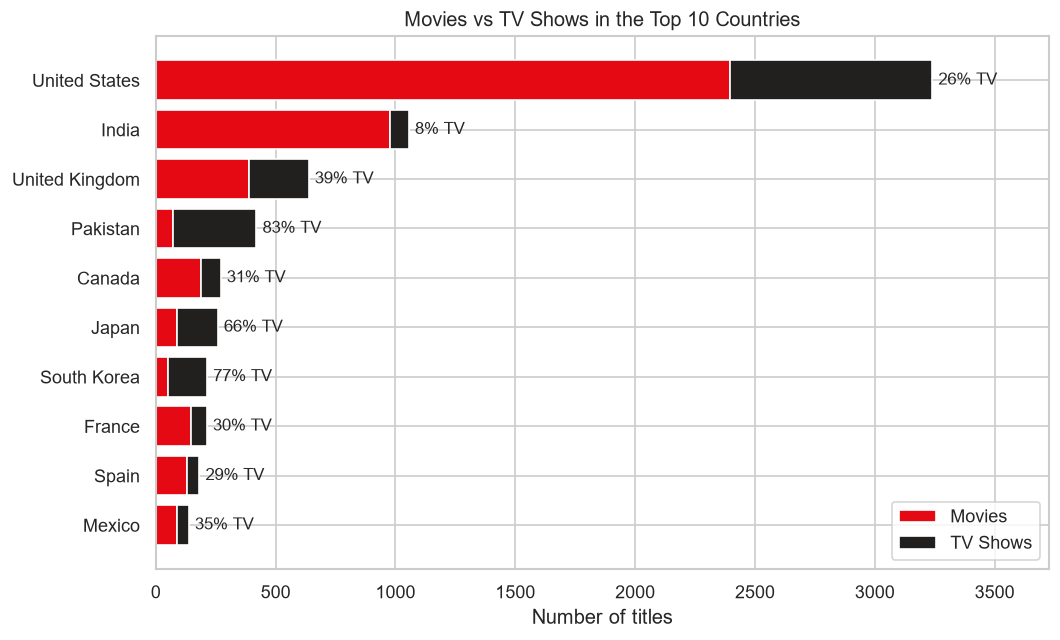

In [22]:
t10 = ranking.head(10).iloc[::-1]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(t10.index, t10['movies'], color=RED, label='Movies')
ax.barh(t10.index, t10['tv_shows'], left=t10['movies'], color=BLACK, label='TV Shows')
for y, (m, t, p) in enumerate(zip(t10['movies'], t10['tv_shows'], t10['tv_share_pct'])):
    ax.text(m + t + 25, y, f'{p:.0f}% TV', va='center', fontsize=10)
ax.set_title('Movies vs TV Shows in the Top 10 Countries')
ax.set_xlabel('Number of titles')
ax.set_xlim(0, t10['titles'].max() * 1.15)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('charts/03_type_split_top10.png', bbox_inches='tight')
plt.show()

### 4.4 TV Show share by country (countries with 50+ titles)

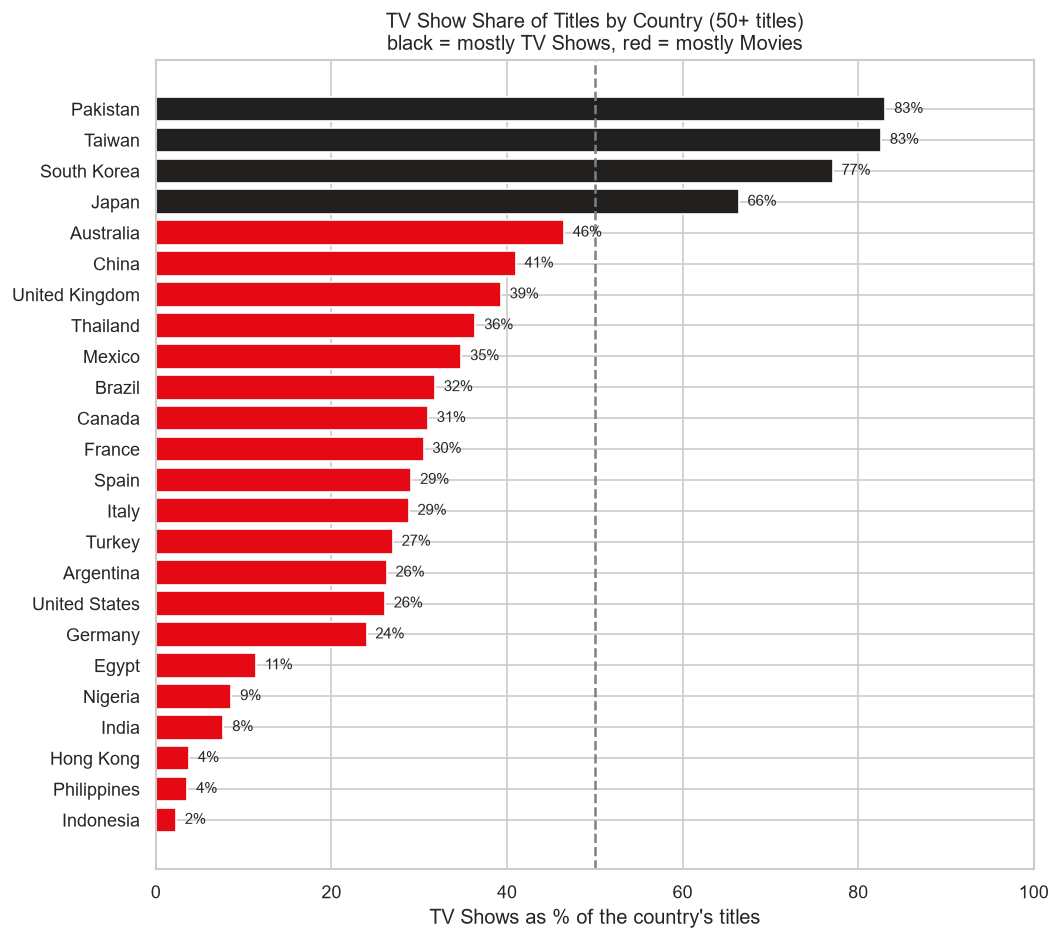

24 countries have 50+ titles.


In [23]:
big = ranking[ranking['titles'] >= 50].sort_values('tv_share_pct')

fig, ax = plt.subplots(figsize=(9, 8))
colors = [BLACK if v >= 50 else RED for v in big['tv_share_pct']]
ax.barh(big.index, big['tv_share_pct'], color=colors)
ax.axvline(50, color='grey', linestyle='--')
for y, v in enumerate(big['tv_share_pct']):
    ax.text(v + 1, y, f'{v:.0f}%', va='center', fontsize=9)
ax.set_title('TV Show Share of Titles by Country (50+ titles)\nblack = mostly TV Shows, red = mostly Movies')
ax.set_xlabel('TV Shows as % of the country\'s titles')
ax.set_xlim(0, 100)
plt.tight_layout()
plt.savefig('charts/04_tv_share_by_country.png', bbox_inches='tight')
plt.show()
print(f"{len(big)} countries have 50+ titles.")

### 4.5 Growth of the top 5 countries over time (by year added)

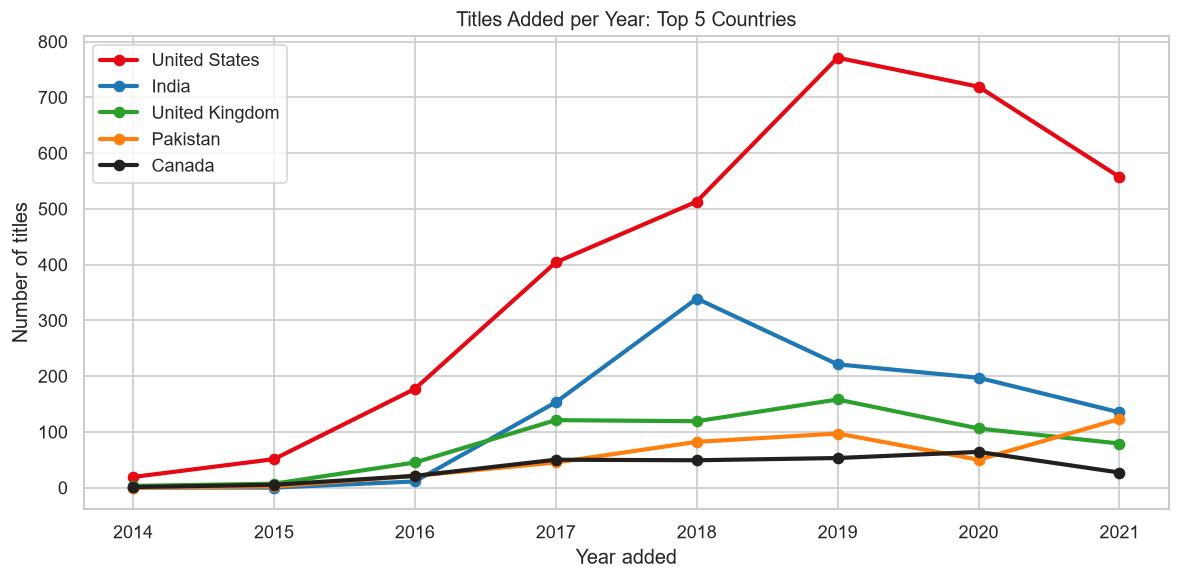

country,United States,India,United Kingdom,Pakistan,Canada
year_added,,,,,
2014,19,0,3,0,1
2015,51,0,7,2,5
2016,177,11,45,21,21
2017,404,153,121,45,50
2018,513,339,119,82,49
2019,771,221,158,97,53
2020,719,197,106,50,64
2021,557,135,79,123,27


In [24]:
top5_names = ranking.head(5).index.tolist()
trend = (known[known['country'].isin(top5_names)]
         .groupby(['year_added', 'country']).size().unstack(fill_value=0)[top5_names])
trend = trend[trend.index >= 2014]

fig, ax = plt.subplots(figsize=(10, 5))
palette = [RED, '#1F77B4', '#2CA02C', '#FF7F0E', BLACK]
for name, color in zip(top5_names, palette):
    ax.plot(trend.index, trend[name], marker='o', linewidth=2.5, color=color, label=name)
ax.set_title('Titles Added per Year: Top 5 Countries')
ax.set_xlabel('Year added')
ax.set_ylabel('Number of titles')
ax.set_xticks(trend.index)
ax.legend()
plt.tight_layout()
plt.savefig('charts/05_top5_trend.png', bbox_inches='tight')
plt.show()
trend

*Note: the dataset ends in September 2021, so 2021 is a partial year.*

### 4.6 Combined country dashboard

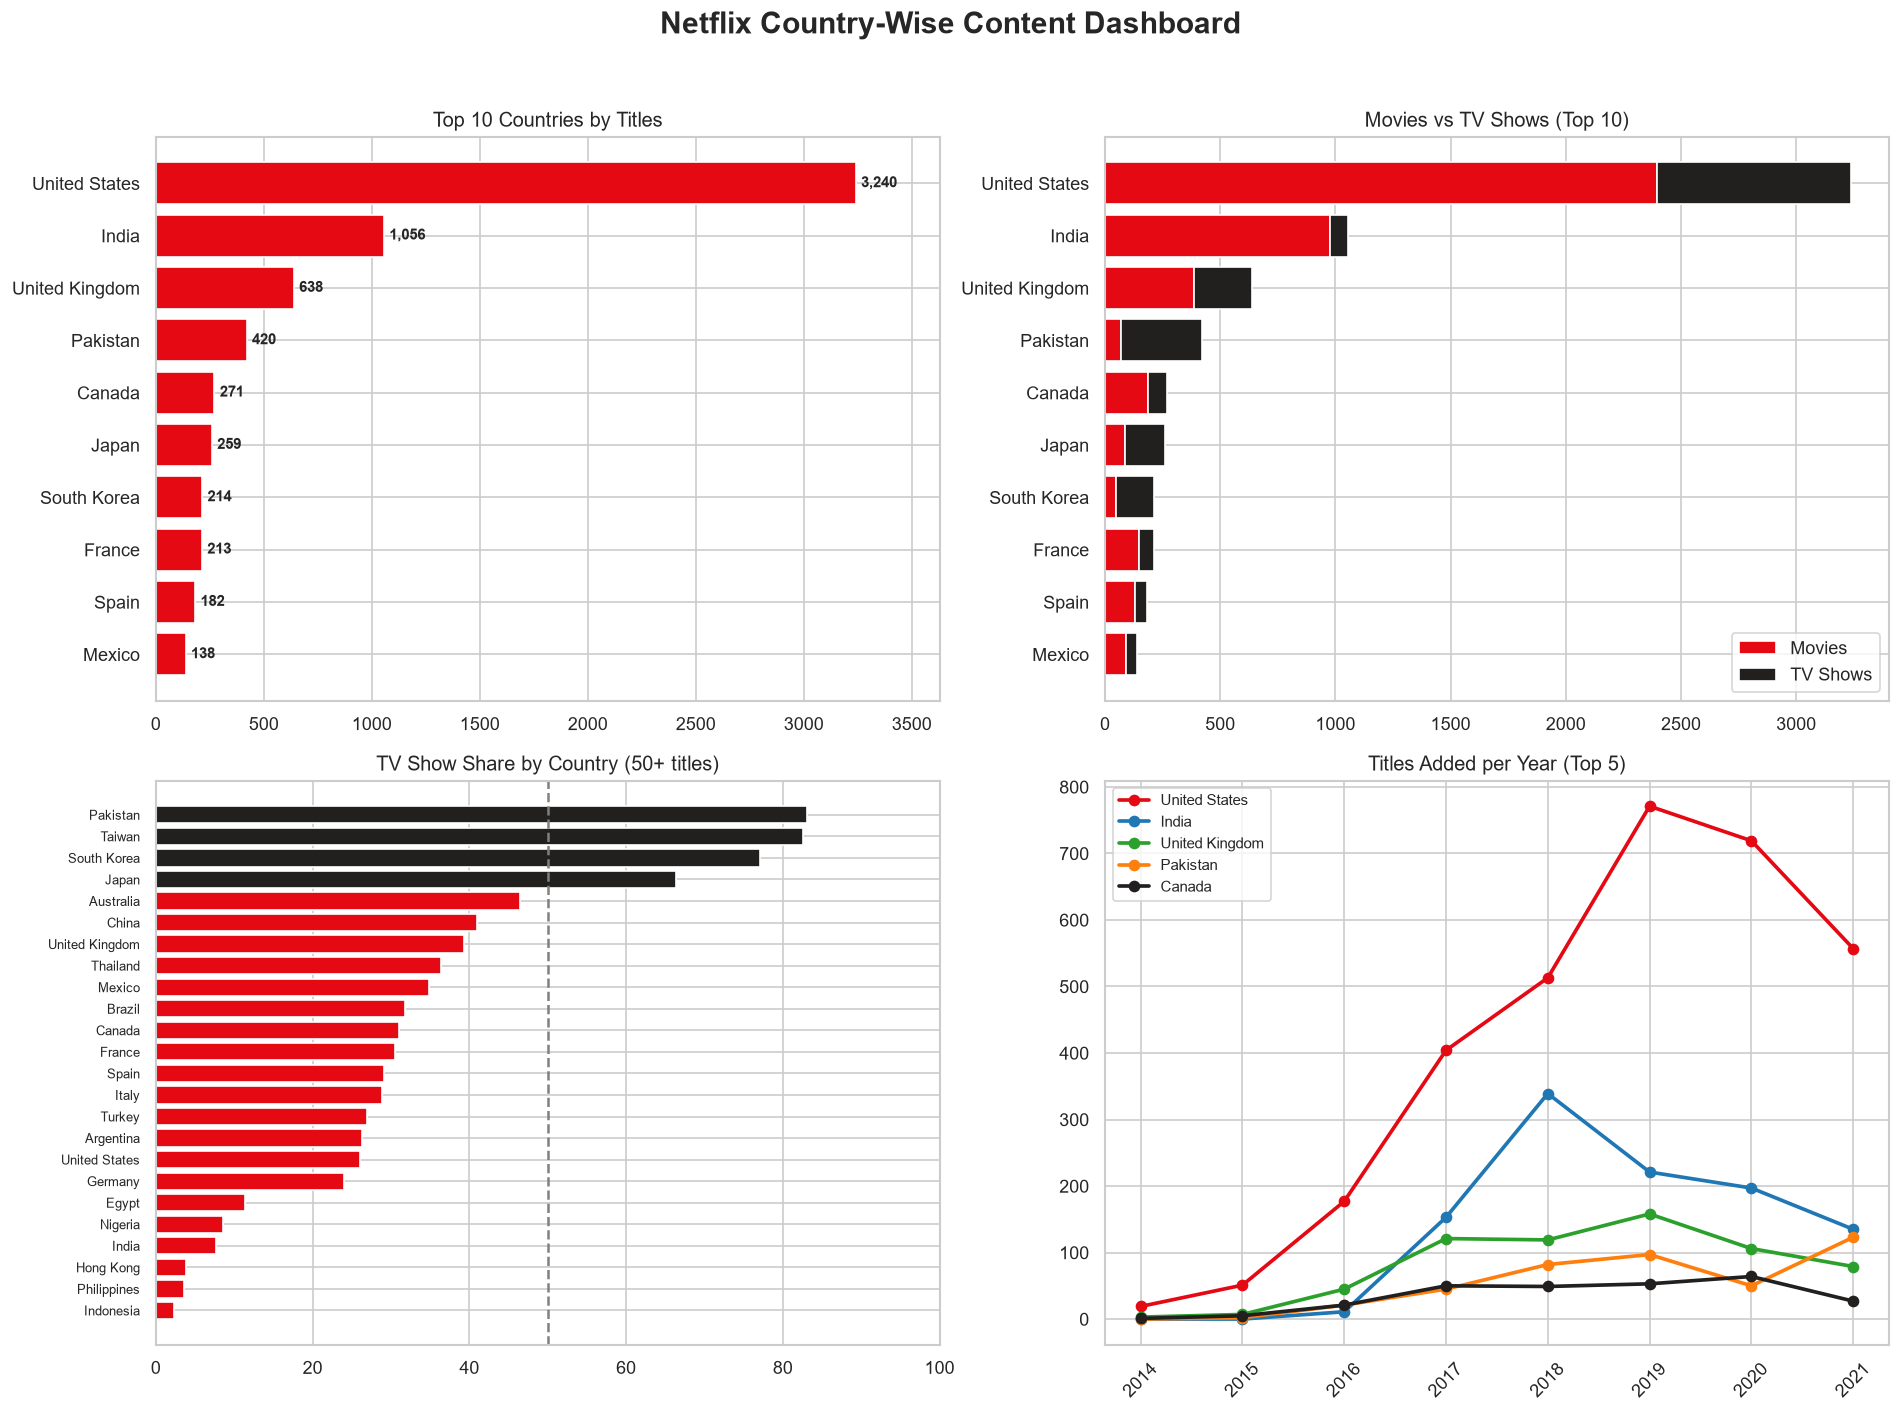

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Netflix Country-Wise Content Dashboard', fontsize=18, fontweight='bold')

# (a) Top 10 by titles
a = ranking.head(10).iloc[::-1]
axes[0, 0].barh(a.index, a['titles'], color=RED)
for y, v in enumerate(a['titles']):
    axes[0, 0].text(v + 25, y, f'{v:,}', va='center', fontsize=9, fontweight='bold')
axes[0, 0].set_title('Top 10 Countries by Titles')
axes[0, 0].set_xlim(0, a['titles'].max() * 1.12)

# (b) Movies vs TV top 10
axes[0, 1].barh(a.index, a['movies'], color=RED, label='Movies')
axes[0, 1].barh(a.index, a['tv_shows'], left=a['movies'], color=BLACK, label='TV Shows')
axes[0, 1].set_title('Movies vs TV Shows (Top 10)')
axes[0, 1].legend(loc='lower right')

# (c) TV share, 50+ titles
b = ranking[ranking['titles'] >= 50].sort_values('tv_share_pct')
axes[1, 0].barh(b.index, b['tv_share_pct'], color=[BLACK if v >= 50 else RED for v in b['tv_share_pct']])
axes[1, 0].axvline(50, color='grey', linestyle='--')
axes[1, 0].set_title('TV Show Share by Country (50+ titles)')
axes[1, 0].set_xlim(0, 100)
axes[1, 0].tick_params(axis='y', labelsize=8)

# (d) Top 5 trend
for name, color in zip(top5_names, palette):
    axes[1, 1].plot(trend.index, trend[name], marker='o', linewidth=2.2, color=color, label=name)
axes[1, 1].set_title('Titles Added per Year (Top 5)')
axes[1, 1].set_xticks(trend.index)
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend(fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('charts/06_country_dashboard.png', bbox_inches='tight')
plt.show()

## Step 5: Generate business insights
### Key findings (calculated from the data)

In [26]:
tv_heavy = big[big['tv_share_pct'] >= 50].sort_values('tv_share_pct', ascending=False)
movie_heavy = big.sort_values('tv_share_pct').head(3)
us_share = ranking['share_pct'].iloc[0]

print('KEY FINDINGS')
print('-' * 70)
print(f"1. {total_known:,} titles have a known country across {len(ranking)} countries ({(df_c['country'] == 'Unknown').sum()} titles are Unknown and excluded).")
print(f"2. {ranking.index[0]} leads with {ranking['titles'].iloc[0]:,} titles ({us_share:.1f}%), followed by {ranking.index[1]} ({ranking['titles'].iloc[1]:,}) and {ranking.index[2]} ({ranking['titles'].iloc[2]:,}).")
print(f"3. The top 5 countries hold {top5['titles'].sum() / total_known * 100:.0f}% of titles and the top 10 hold {top10['titles'].sum() / total_known * 100:.0f}%.")
print(f"4. {(ranking['titles'] <= 5).sum()} of {len(ranking)} countries have 5 titles or fewer (a long tail).")
print(f"5. Mostly-TV countries (50+ titles): {', '.join(f'{c} ({v:.0f}%)' for c, v in tv_heavy['tv_share_pct'].items())}.")
print(f"6. Most movie-heavy: {', '.join(f'{c} ({100 - v:.0f}% movies)' for c, v in movie_heavy['tv_share_pct'].items())}.")
peak_india = trend['India'].idxmax()
print(f"7. India's additions peaked in {peak_india} ({trend['India'].max()} titles); the United States peaked in {trend['United States'].idxmax()} ({trend['United States'].max()} titles).")

KEY FINDINGS
----------------------------------------------------------------------
1. 8,499 titles have a known country across 85 countries (287 titles are Unknown and excluded).
2. United States leads with 3,240 titles (38.1%), followed by India (1,056) and United Kingdom (638).
3. The top 5 countries hold 66% of titles and the top 10 hold 78%.
4. 33 of 85 countries have 5 titles or fewer (a long tail).
5. Mostly-TV countries (50+ titles): Pakistan (83%), Taiwan (83%), South Korea (77%), Japan (66%).
6. Most movie-heavy: Indonesia (98% movies), Philippines (96% movies), Hong Kong (96% movies).
7. India's additions peaked in 2018 (339 titles); the United States peaked in 2019 (771 titles).


### Business insights
- **The catalogue is heavily concentrated.** The United States alone supplies about 38% of titles with a known country, and five countries supply about two thirds. Netflix's library depends strongly on a few production hubs.
- **India is a clear second hub** (about 12%), with yearly additions rising from 11 titles in 2016 to 339 in 2018.
- **Production style differs by country.** Pakistan, Taiwan, South Korea and Japan are mostly TV Shows, while Indonesia, the Philippines, Hong Kong, India, Egypt and Nigeria are overwhelmingly movies (about 90% or more). Content strategy and licensing deals should reflect each market's preferred format.
- **There is a long tail of small markets.** 33 of the 85 countries (about 4 in 10) have five titles or fewer, so many regions are barely represented.
- **Recommendations:**
  1. Protect the core hubs (US, India, UK) since they carry the catalogue.
  2. Expand series content from TV-strong countries (South Korea, Japan, Pakistan, Taiwan), because series can keep audiences engaged across several seasons.
  3. Grow film and series from under-represented regions to widen local appeal.

*Insights come from this dataset only (titles up to September 2021). Each title lists a single country, so co-productions are counted once under their primary country, and 287 titles with an unknown country are excluded.*

## Summary
| Item | Result |
|---|---|
| Dataset | `netflix_cleaned.csv` (8,786 titles, 8,499 with a known country) |
| Countries analyzed | 85 |
| Ranking report | `country_ranking.csv` |
| Charts saved | `Task3/charts/` (6 PNG files) |
| Skills used | Pandas GroupBy, aggregation, explode, Matplotlib, Seaborn |